# Customer Lifetime Value (CLV) Prediction Model

This notebook trains BG/NBD and Gamma-Gamma models for predicting Customer Lifetime Value (CLV).

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import plot_period_transactions, plot_frequency_recency_matrix
from sklearn.metrics import mean_squared_error, r2_score
import joblib



## 1. Load and Explore Data

In [2]:
# Load the dataset
print("Loading data...")
df = pd.read_csv('customer_lifetime_value_prediction.csv')
print(f"Dataset loaded with {len(df)} rows and {len(df.columns)} columns")

# Display basic information
print("\nDataset info:")
df.info()

Loading data...
Dataset loaded with 4186 rows and 14 columns

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4186 entries, 0 to 4185
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           4186 non-null   int64  
 1   Customer ID          4186 non-null   float64
 2   frequency            4186 non-null   float64
 3   recency              4186 non-null   float64
 4   T                    4186 non-null   float64
 5   monetary_value       4186 non-null   float64
 6   p_not_alive          4186 non-null   float64
 7   p_alive              4186 non-null   float64
 8   predicted_purchases  4186 non-null   float64
 9   actual30             4186 non-null   float64
 10  error                4186 non-null   float64
 11  expected_avg_sales_  4186 non-null   float64
 12  predicted_clv        4186 non-null   float64
 13  profit_margin        4186 non-null   float64
dtypes: float64(1

In [3]:
# Display basic statistics
print("\nBasic statistics:")
df.describe()


Basic statistics:


,Unnamed: 0,Customer ID,frequency,recency,T,monetary_value,p_not_alive,p_alive,predicted_purchases,actual30,error,expected_avg_sales_,predicted_clv,profit_margin
count,4186.000000,4186.000000,4186.000000,4186.000000,4186.000000,4.186000e+03,4186.000000,4.186000e+03,4.186000e+03,4186.000000,4186.000000,4186.000000,4.186000e+03,4.186000e+03
mean,2954.991400,15300.991400,7.708791,388.930005,525.263258,3.305819e+02,0.155542,8.444576e-01,4.000107e-01,0.763734,0.363724,650.368930,4.495622e+03,2.247811e+02
std,1699.118817,1699.118817,12.810148,227.742674,203.849750,3.803325e+02,0.254135,2.541349e-01,5.210494e-01,1.608483,1.528458,1150.691702,1.493439e+04,7.467196e+02
min,1.000000,12347.000000,1.000000,1.000000,9.000000,1.776357e-15,0.000000,1.380835e-10,2.398896e-10,0.043415,-0.055814,1.512222,3.900037e-07,1.950018e-08
25%,1488.250000,13834.250000,2.000000,187.000000,409.000000,1.607338e+02,0.005573,8.174503e-01,1.157008e-01,0.243902,0.018526,228.410803,8.500520e+02,4.250260e+01
50%,2942.500000,15288.500000,4.000000,392.000000,591.000000,2.475917e+02,0.024508,9.754919e-01,2.575232e-01,0.451795,0.079316,361.366693,2.039092e+03,1.019546e+02
75%,4425.750000,16771.750000,9.000000,596.000000,694.000000,3.810400e+02,0.182550,9.944275e-01,5.068385e-01,0.816922,0.272326,640.463012,4.338300e+03,2.169150e+02
max,5941.000000,18287.000000,284.000000,738.000000,738.000000,8.513271e+03,1.000000,1.000000e+00,1.062385e+01,30.000000,29.996008,33107.133027,4.941547e+05,2.470774e+04


## 2. Data Visualization


Generating visualizations...


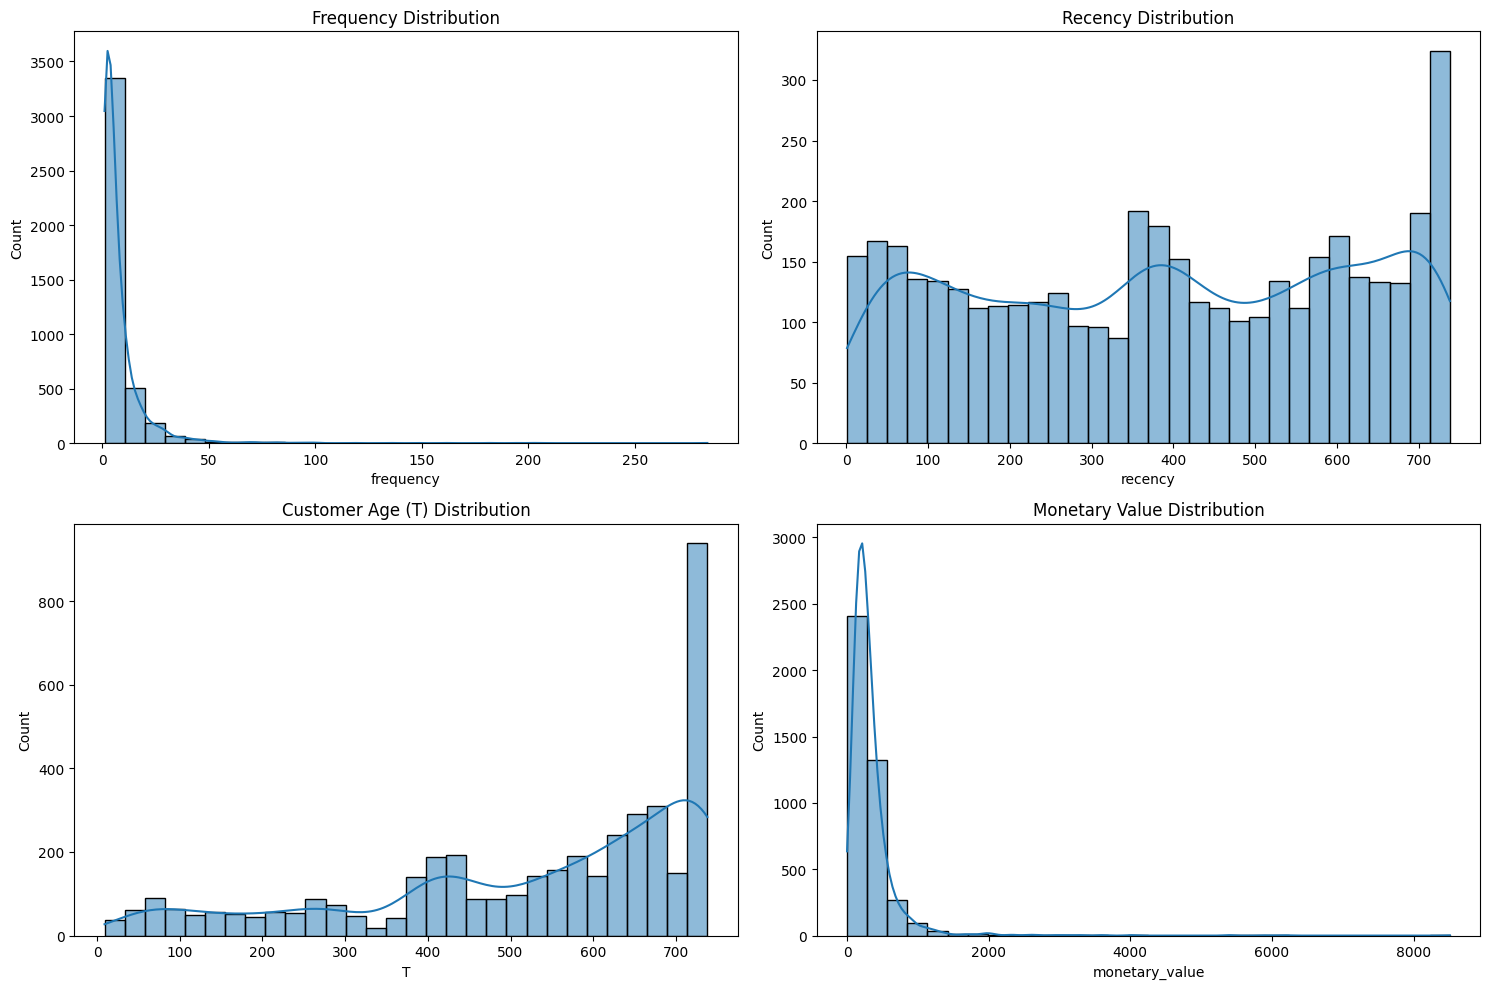

Saved data distributions plot as 'data_distributions.png'


In [4]:
# Visualize the distribution of key features
print("\nGenerating visualizations...")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['frequency'], bins=30, kde=True)
plt.title('Frequency Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df['recency'], bins=30, kde=True)
plt.title('Recency Distribution')

plt.subplot(2, 2, 3)
sns.histplot(df['T'], bins=30, kde=True)
plt.title('Customer Age (T) Distribution')

plt.subplot(2, 2, 4)
sns.histplot(df['monetary_value'], bins=30, kde=True)
plt.title('Monetary Value Distribution')

plt.tight_layout()
plt.savefig('data_distributions.png')
plt.show()
print("Saved data distributions plot as 'data_distributions.png'")

## 3. Prepare Data for Modeling

In [5]:
# Train-test split
print("\nSplitting data into calibration and holdout sets...")
calibration_end_date = df['T'].max() * 0.7  # 70% for calibration
calibration_data = df[df['T'] <= calibration_end_date]
holdout_data = df[df['T'] > calibration_end_date]

print(f"Calibration period: 0 to {calibration_end_date:.0f} days")
print(f"Holdout period: {calibration_end_date:.0f} to {df['T'].max():.0f} days")
print(f"Calibration data shape: {calibration_data.shape}")
print(f"Holdout data shape: {holdout_data.shape}")


Splitting data into calibration and holdout sets...
Calibration period: 0 to 517 days
Holdout period: 517 to 738 days
Calibration data shape: (1615, 14)
Holdout data shape: (2571, 14)


## 4. Train BG/NBD Model


Training BG/NBD model...
Optimization terminated successfully.
         Current function value: -4.249390
         Iterations: 19
         Function evaluations: 20
         Gradient evaluations: 20


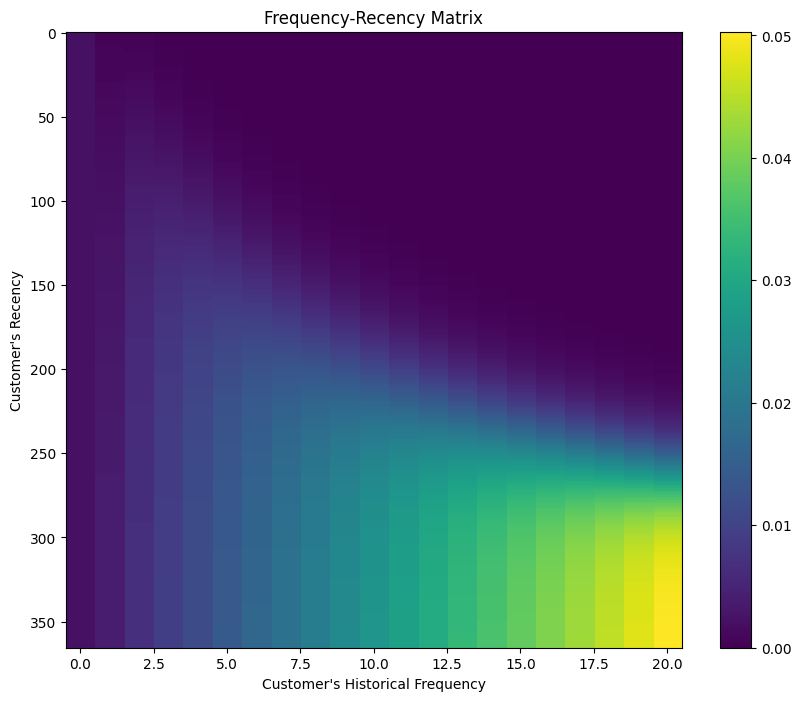

Saved frequency-recency matrix as 'frequency_recency_matrix.png'


In [6]:
# Train the BG/NBD model
print("\nTraining BG/NBD model...")
bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(calibration_data['frequency'], 
        calibration_data['recency'], 
        calibration_data['T'],
        verbose=True)

# Plot frequency/recency matrix
plt.figure(figsize=(10, 8))
plot_frequency_recency_matrix(bgf, max_frequency=20, max_recency=365)
plt.title('Frequency-Recency Matrix')
plt.savefig('frequency_recency_matrix.png')
plt.show()
print("Saved frequency-recency matrix as 'frequency_recency_matrix.png'")

## 5. Train Gamma-Gamma Model

In [7]:
# Train the Gamma-Gamma model
print("\nTraining Gamma-Gamma model...")
ggf = GammaGammaFitter(penalizer_coef=0.1)
ggf.fit(calibration_data['frequency'], 
        calibration_data['monetary_value'],
        verbose=True)


Training Gamma-Gamma model...
Optimization terminated successfully.
         Current function value: 8.220212
         Iterations: 13
         Function evaluations: 14
         Gradient evaluations: 14


<lifetimes.GammaGammaFitter: fitted with 1615 subjects, p: 1.01, q: 0.19, v: 0.95>

## 6. Make Predictions

In [8]:
# Make predictions on calibration data
print("\nMaking predictions on calibration data...")
prediction_days = 30
calibration_data['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    prediction_days,
    calibration_data['frequency'],
    calibration_data['recency'],
    calibration_data['T']
)

calibration_data['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    calibration_data['frequency'],
    calibration_data['recency'],
    calibration_data['T'],
    calibration_data['monetary_value'],
    time=prediction_days/30,  # Convert to months
    freq='D'  # Daily frequency
)

# Make predictions on holdout data
print("Making predictions on holdout data...")
holdout_data['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    prediction_days,
    holdout_data['frequency'],
    holdout_data['recency'],
    holdout_data['T']
)

holdout_data['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    holdout_data['frequency'],
    holdout_data['recency'],
    holdout_data['T'],
    holdout_data['monetary_value'],
    time=prediction_days/30,
    freq='D'
)


Making predictions on calibration data...
Making predictions on holdout data...


## 7. Model Evaluation


Model Evaluation:
RMSE: 0.9872
R² Score: 0.2067


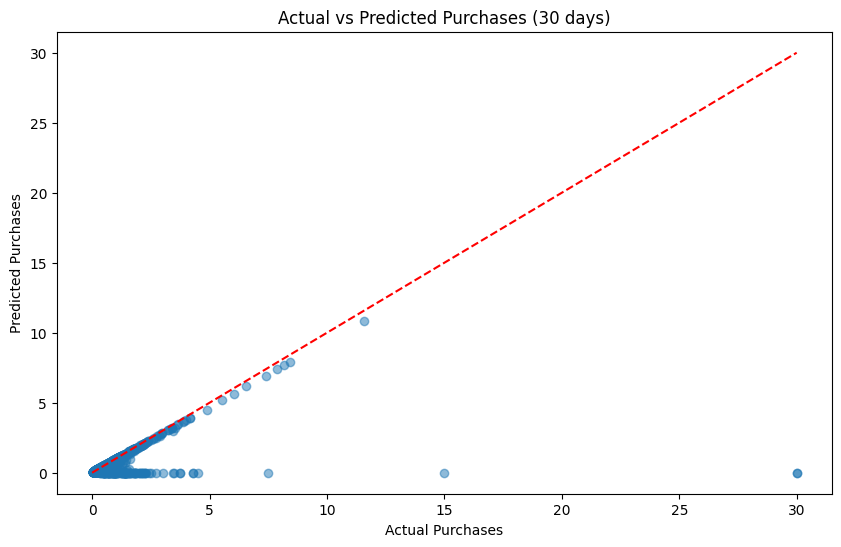

Saved actual vs predicted plot as 'actual_vs_predicted.png'


In [9]:
# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(holdout_data['actual30'], holdout_data['predicted_purchases']))
r2 = r2_score(holdout_data['actual30'], holdout_data['predicted_purchases'])

print(f"\nModel Evaluation:")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(holdout_data['actual30'], holdout_data['predicted_purchases'], alpha=0.5)
plt.plot([0, holdout_data['actual30'].max()], [0, holdout_data['actual30'].max()], 'r--')
plt.xlabel('Actual Purchases')
plt.ylabel('Predicted Purchases')
plt.title('Actual vs Predicted Purchases (30 days)')
plt.savefig('actual_vs_predicted.png')
plt.show()
print("Saved actual vs predicted plot as 'actual_vs_predicted.png'")

## 8. Save Models

In [10]:
# Save the models
print("\nSaving models...")
joblib.dump(bgf, 'bgf_model.pkl')
joblib.dump(ggf, 'ggf_model.pkl')
print("Models saved successfully as 'bgf_model.pkl' and 'ggf_model.pkl'")


Saving models...
Models saved successfully as 'bgf_model.pkl' and 'ggf_model.pkl'


## 9. Visualize Results

In [11]:
# Top 10 customers by predicted CLV
top_customers = calibration_data.nlargest(10, 'predicted_clv')[['Customer ID', 'frequency', 'recency', 'T', 'monetary_value', 'predicted_clv']]
print("\nTop 10 Customers by Predicted CLV:")
top_customers


Top 10 Customers by Predicted CLV:


,Customer ID,frequency,recency,T,monetary_value,predicted_clv
1234,14096.0,16.0,97.0,101.0,3568.791875,12364.649826
3626,17450.0,36.0,430.0,438.0,5398.388611,12357.116543
1067,13868.0,1.0,31.0,38.0,2685.000000,7668.472641
4089,18139.0,1.0,1.0,18.0,1780.620000,6097.793555
284,12762.0,1.0,18.0,25.0,1436.930000,4779.173872
7,12357.0,1.0,355.0,388.0,6207.670000,3627.904841
1231,14088.0,16.0,411.0,421.0,3106.555000,3473.168788
2195,15444.0,1.0,31.0,40.0,1075.360000,2985.839132
371,12882.0,1.0,24.0,33.0,991.200000,2971.100496
68,12438.0,1.0,126.0,140.0,2016.780000,2703.154254


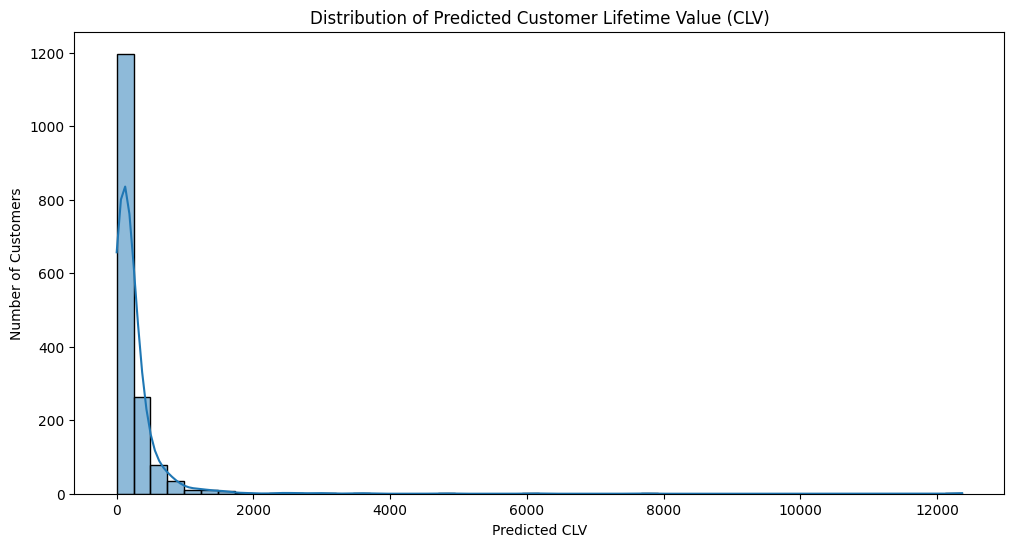

Saved CLV distribution plot as 'clv_distribution.png'


In [12]:
# Plot CLV distribution
plt.figure(figsize=(12, 6))
sns.histplot(calibration_data['predicted_clv'], bins=50, kde=True)
plt.title('Distribution of Predicted Customer Lifetime Value (CLV)')
plt.xlabel('Predicted CLV')
plt.ylabel('Number of Customers')
plt.savefig('clv_distribution.png')
plt.show()
print("Saved CLV distribution plot as 'clv_distribution.png'")


Training Pareto/NBD model...
Optimize function with Nelder-Mead
Optimization terminated successfully.
         Current function value: -7032.004583
         Iterations: 216
         Function evaluations: 372


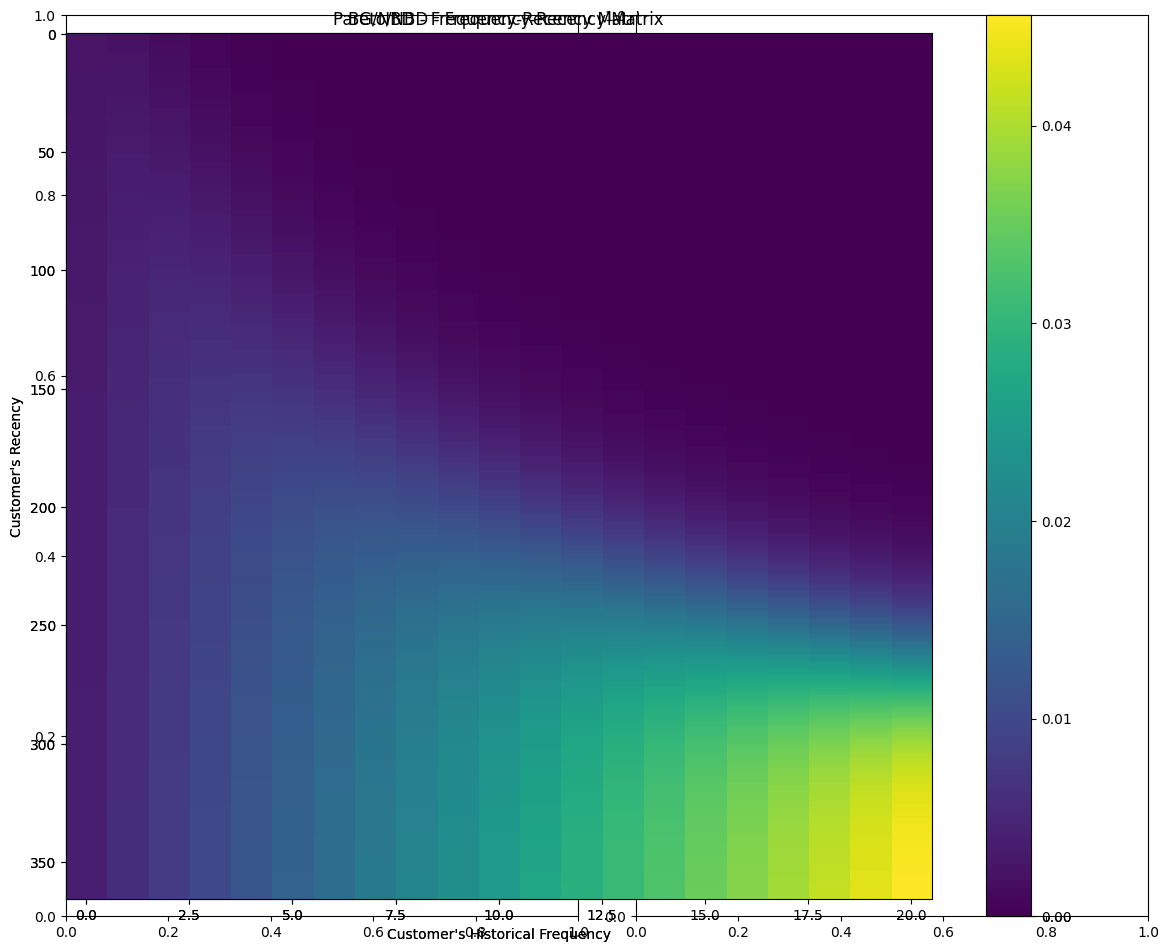

Making predictions with Pareto/NBD on holdout data...

Model Evaluation (30-day predictions):

Model Comparison:
        Model    RMSE      R²
0      BG/NBD  0.9872  0.2067
1  Pareto/NBD  0.9928  0.1977


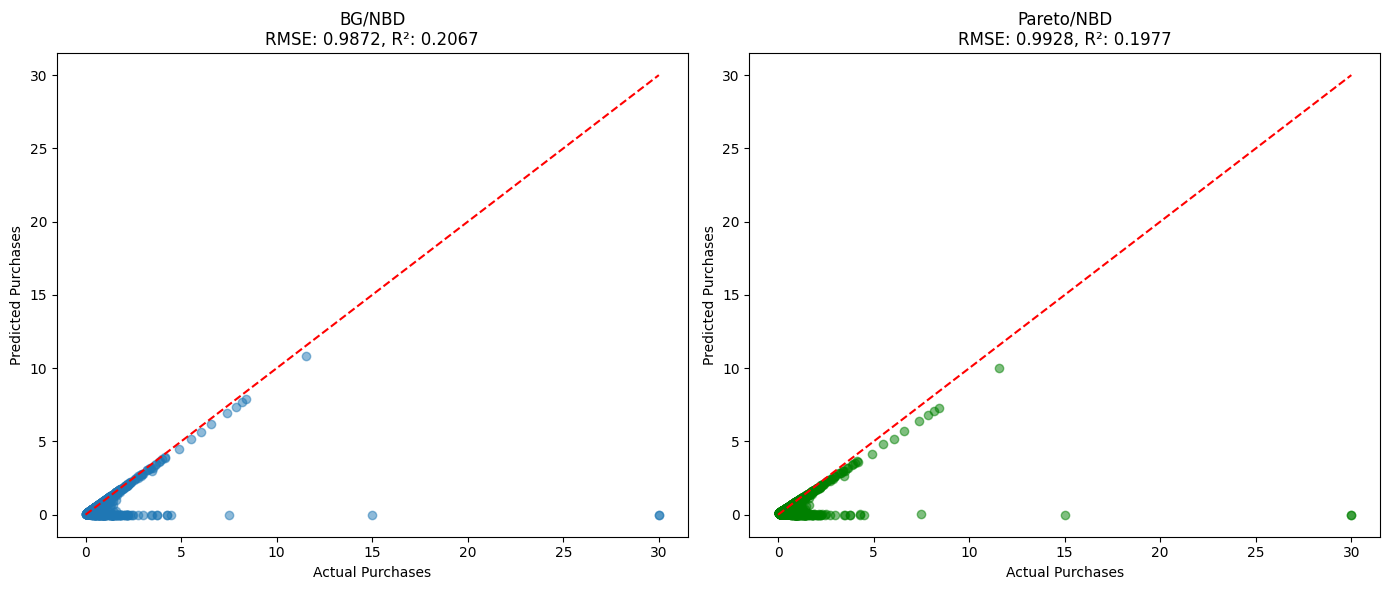


Saving Pareto/NBD model...
Pareto/NBD model saved successfully as 'pnbd_model.pkl'

Pareto/NBD model integration complete!


In [13]:


# 1. Import required libraries (if not already imported)
from lifetimes import ParetoNBDFitter
import matplotlib.pyplot as plt
from lifetimes.plotting import plot_frequency_recency_matrix
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# 2. Train the Pareto/NBD model
print("\nTraining Pareto/NBD model...")
pnbd = ParetoNBDFitter(penalizer_coef=0.1)
pnbd.fit(calibration_data['frequency'], 
         calibration_data['recency'], 
         calibration_data['T'],
         verbose=True)

# 3. Plot frequency/recency matrix for both models side by side
plt.figure(figsize=(12, 10))

plt.subplot(1, 2, 1)
plot_frequency_recency_matrix(bgf, max_frequency=20, max_recency=365)
plt.title('BG/NBD - Frequency-Recency Matrix')

plt.subplot(1, 2, 2)
plot_frequency_recency_matrix(pnbd, max_frequency=20, max_recency=365)
plt.title('Pareto/NBD - Frequency-Recency Matrix')

plt.tight_layout()
plt.show()

# 4. Make predictions with Pareto/NBD on holdout data
print("Making predictions with Pareto/NBD on holdout data...")
holdout_data['pnbd_predicted'] = pnbd.conditional_expected_number_of_purchases_up_to_time(
    prediction_days,
    holdout_data['frequency'],
    holdout_data['recency'],
    holdout_data['T']
)

# 5. Calculate evaluation metrics for both models
print("\nModel Evaluation (30-day predictions):")

# BG/NBD metrics
bgf_rmse = np.sqrt(mean_squared_error(holdout_data['actual30'], holdout_data['predicted_purchases']))
bgf_r2 = r2_score(holdout_data['actual30'], holdout_data['predicted_purchases'])

# Pareto/NBD metrics
pnbd_rmse = np.sqrt(mean_squared_error(holdout_data['actual30'], holdout_data['pnbd_predicted']))
pnbd_r2 = r2_score(holdout_data['actual30'], holdout_data['pnbd_predicted'])

# Print metrics
eval_metrics = pd.DataFrame({
    'Model': ['BG/NBD', 'Pareto/NBD'],
    'RMSE': [bgf_rmse, pnbd_rmse],
    'R²': [bgf_r2, pnbd_r2]
})

print("\nModel Comparison:")
print(eval_metrics.round(4))

# 6. Plot actual vs predicted for both models
plt.figure(figsize=(14, 6))

# BG/NBD predictions
plt.subplot(1, 2, 1)
plt.scatter(holdout_data['actual30'], holdout_data['predicted_purchases'], alpha=0.5)
plt.plot([0, holdout_data['actual30'].max()], [0, holdout_data['actual30'].max()], 'r--')
plt.xlabel('Actual Purchases')
plt.ylabel('Predicted Purchases')
plt.title(f'BG/NBD\nRMSE: {bgf_rmse:.4f}, R²: {bgf_r2:.4f}')

# Pareto/NBD predictions
plt.subplot(1, 2, 2)
plt.scatter(holdout_data['actual30'], holdout_data['pnbd_predicted'], alpha=0.5, color='green')
plt.plot([0, holdout_data['actual30'].max()], [0, holdout_data['actual30'].max()], 'r--')
plt.xlabel('Actual Purchases')
plt.ylabel('Predicted Purchases')
plt.title(f'Pareto/NBD\nRMSE: {pnbd_rmse:.4f}, R²: {pnbd_r2:.4f}')

plt.tight_layout()
plt.show()

# 7. Save the Pareto/NBD model
print("\nSaving Pareto/NBD model...")
joblib.dump(pnbd, 'pnbd_model.pkl')
print("Pareto/NBD model saved successfully as 'pnbd_model.pkl'")

# 8. Add Pareto/NBD predictions to the calibration data for future use
calibration_data['pnbd_predicted'] = pnbd.conditional_expected_number_of_purchases_up_to_time(
    prediction_days,
    calibration_data['frequency'],
    calibration_data['recency'],
    calibration_data['T']
)

print("\nPareto/NBD model integration complete!")